In [1]:
%run Packages_and_Functions.ipynb


In [2]:
# Check the probability that w_1 > w_2 + w_3. We know that distribution now!
t = 70 #partition finess
trials = 600
eps = 10e-5
y = np.zeros(t)
p = np.linspace(0+eps,1-eps,t)
for i in range(t):
    broken = 0
    for k in range(trials):
        L = np.random.geometric(1-p[i],3) #random weights on a triangle
        L = L
        for j in range(3):
#             if L[0] > 0 and L[1] > 0 and L[2] > 0 and L[j] > L[(j+1)%3] + L[(j+2 )%3]:
            if L[j] > L[(j+1)%3] + L[(j+2 )%3]:
                broken +=1
                break
    y[i] = broken/trials
    


In [ ]:
pos_weights = 0
trial_num = 5000
delta = 20  #partition parameter
eps = 10e-5  # make sure we don't use prob 0 or 1
p = np.linspace(0+eps,1-eps,delta)
prob = np.zeros(delta)
for i in range(delta):
    tot_broken = 0
    q = 1-p[i]
    for itn in range(trial_num):
        w = np.random.geometric(q,3)
        if not pos_weights:
            w = w - np.ones(3)
        if w[0] > w[1] + w[2]:
            tot_broken +=1
    prob[i] = tot_broken/trial_num


In [ ]:
plt.plot(p,prob)
fx = lambda x: (x)/(1+x)**2
plt.plot(p,[fx(v) for v in p])

plt.show()

In [ ]:
### Computation showed that 1/n^{.5} is threshold for broken cycles. We know that 1/n is threshold for cycles in general - so let's test this

# when plotting this - x asis = P, y axis = number of cycles (and have two plots - general number of cycles, and broken cycles)
P = np.linspace(1.3,0.1,50)
N = range(20,25,5)
broken_Res = np.zeros((len(N),len(P)))
general_Res= np.zeros((len(N),len(P)))
trial_num = 30
for i,n in enumerate(N):
#     if n%5 == 0:
#     print(n)
    for j,q in enumerate(P):
        if j%5 == 0:
            print(j)
        p = 1/np.power(n,q)
        tot = 0
        for trial in range(trial_num):
            G = random_geometric_weighted_graph(n,p)
            
            while G.size() == 0:
                G = random_geometric_weighted_graph(n,p)
            w = get_weights_vector(G,make_index_encoding(G))
            phi = cycle_matrix(G)
            V = phi@w # potential deficit values for cycles
            tot +=np.count_nonzero(V < 0)
        broken_Res[i][j] = tot/trial_num
        general_Res[i][j] = count_simple_cycles(G) # this is super duper exponential time - maybe run like, once.
            



In [3]:
### This code is to check if 1/sqrt(n) is a threshold for broken TRIANGLES - so computations for this will suffice

# when plotting this - x asis = P, y axis = number of cycles (and have two plots - general number of cycles, and broken cycles)
P = np.linspace(1.3,0.1,50)
N = range(20,21)
broken_Res = np.zeros((len(N),len(P)))
general_Res= np.zeros((len(N),len(P)))
trial_num = 30
for i,n in enumerate(N):
#     if n%5 == 0:
    print(n)
    for j,q in enumerate(P):
        if j%5 == 0:
            print(j)
        p = 1/np.power(n,q)
        tot = 0ins
        
        for trial in range(trial_num):
            G = random_geometric_weighted_graph(n,p)
            
            while G.size() == 0:
                G = random_geometric_weighted_graph(n,p)
            w = get_weights_vector(G,make_index_encoding(G))
            phi = metric_triangles_mtx(G)
            V = phi@w # potential deficit values for cycles
            tot +=np.count_nonzero(V < 0)
        broken_Res[i][j] = tot/trial_num
        general_Res[i][j] = count_simple_cycles(G,kmax=3) # Count only triangles
            



20
0
5
10
15
20
25
30
35
40
45


In [10]:
df = pd.DataFrame(broken_Res)
df.to_csv("broken_Res.csv")


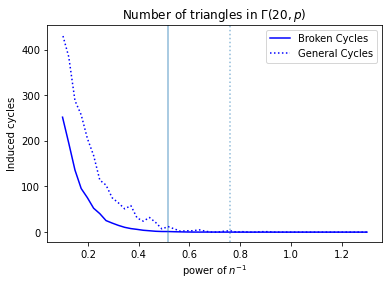

In [9]:
# broken_Res
# Q = [f"$1/n^{round(p,2)}$" for p in np.flip(P)]
# print(P) 
# Q = [round(p,2) for p in P]
# print(Q)
N = range(20,25,5)

# for i,n in enumerate(N):
#     plt.plot(np.flip(P),broken_Res[i], label = "n = " + str(n)+", broken")
#     plt.plot(np.flip(P),general_Res[i], label = "n = " + str(n)+", general")
plt.plot(P,broken_Res[0], label = "Broken Cycles",color="blue")
plt.axvline(P[np.argmax(broken_Res[0] >1)],alpha=.5)
plt.plot(P,general_Res[0], label = "General Cycles",color="blue",linestyle = 'dotted')
plt.axvline(P[np.argmax(general_Res[0] >1)],alpha=.5,linestyle='dotted')
# plt.plot(P,broken_Res[1], label = "Broken Cycles",color="red")
# plt.axvline(P[np.argmax(broken_Res[0] >1)],alpha=.5)
# plt.plot(P,general_Res[1], label = "General Cycles",color="red",linestyle = 'dotted')
# plt.axvline(P[np.argmax(general_Res[0] >1)],alpha=.5,linestyle='dotted')

plt.xlabel("power of $n^{-1}$")
plt.ylabel("Induced cycles")
plt.yscale("linear")
plt.title("Number of triangles in $\Gamma(20,p)$")
plt.legend()
# plt.savefig("threshold.svg")

In [ ]:
####### THIS IS FOR A UNIFORM WEIGHTED GRAPH ########
### Computation showed that 1/n^{.5} is threshold for broken cycles. We know that 1/n is threshold for cycles in general - so let's test this

# when plotting this - x asis = P, y axis = number of cycles (and have two plots - general number of cycles, and broken cycles)
P = np.linspace(1.3,.2,50)
N = range(20,24,5)
broken_Res = np.zeros((len(N),len(P)))
general_Res= np.zeros((len(N),len(P)))
trial_num = 50
for i,n in enumerate(N):
#     if n%5 == 0:
    print(n)
    for j,q in enumerate(P):
        if j%5 == 0:
            print(j)
        p = 1/np.power(n,q)
        tot = 0
        for trial in range(trial_num):
            G = random_uniform_weighted_graph(n,p)
            
            while G.size() == 0:
                G = random_uniform_weighted_graph(n,p)
            w = get_weights_vector(G,make_index_encoding(G))
            phi = cycle_matrix(G)
            V = phi@w # potential deficit values for cycles
            tot +=np.count_nonzero(V < 0)
        broken_Res[i][j] = tot/trial_num
        general_Res[i][j] = count_simple_cycles(G) # this is super duper exponential time - maybe run like, once.
            



In [ ]:
# broken_Res
# Q = [f"$1/n^{round(p,2)}$" for p in np.flip(P)]
print(P)
# Q = [round(p,2) for p in P]
# print(Q)
N = range(20,25,5)

# for i,n in enumerate(N):
#     plt.plot(np.flip(P),broken_Res[i], label = "n = " + str(n)+", broken")
#     plt.plot(np.flip(P),general_Res[i], label = "n = " + str(n)+", general")
plt.plot(P,broken_Res[0], label = "Broken Cycles",color="blue")
plt.axvline(P[np.argmax(broken_Res[0] >5)],alpha=.5)
plt.plot(P,general_Res[0], label = "General Cycles",color="blue",linestyle = 'dotted')
plt.axvline(P[np.argmax(general_Res[0] >5)],alpha=.5,linestyle='dotted')

plt.xlabel("power of $n^{-1}$")
plt.ylabel("Induced cycles")
# plt.yscale("log")
plt.title("Number of induced cycles in $\Gamma(20,p)$")
plt.legend()
plt.savefig("threshold.svg")